# 20 — Aggregate across buckets

Combine bucket Kb and Sb amounts into one capital amount for each risk class.

Across-bucket correlation gamma permits only the diversification prescribed between different regulatory buckets.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

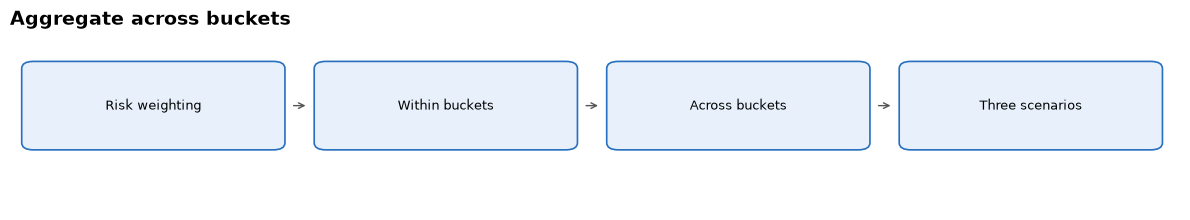

In [2]:
draw_flow(['Risk weighting', 'Within buckets', 'Across buckets', 'Three scenarios'],'Aggregate across buckets',wrap_after=4)

Use the same square-root structure, now with bucket results instead of individual factors.

$$K_{class}=\sqrt{\sum_bK_b^2+\sum_b\sum_{c
e b}\gamma_{bc}S_bS_c}$$

In [3]:
from frtb_engine.parameters import cross_bucket_correlation
buckets=pd.read_csv(RUN/'08_sbm_bucket_results.csv')
sample=buckets[(buckets.scenario=='medium')&(buckets.risk_measure=='DELTA')&(buckets.risk_class=='GIRR')].dropna(subset=['k_bucket']).copy()
records=sample.to_dict('records'); variance=sum(row['k_bucket']**2 for row in records); pairs=[]
for i,left in enumerate(records):
    for right in records[i+1:]:
        gamma=cross_bucket_correlation('GIRR',str(left['bucket']),str(right['bucket']),'medium')
        variance+=2*gamma*left['s_bucket']*right['s_bucket']
        pairs.append({'bucket 1':left['bucket'],'bucket 2':right['bucket'],'gamma':gamma})
display(crore_table(sample[['bucket','k_bucket','s_bucket']],['k_bucket','s_bucket']))
display_sample(percent_columns(pd.DataFrame(pairs),['gamma']),12)
print(f"GIRR delta capital: INR {np.sqrt(max(variance,0))/INR_CRORE:,.4f} crore")

,bucket,K Bucket (INR crore),S Bucket (INR crore)
41,EUR,2.0221,-1.9715
42,INR,2.2454,0.6290
43,USD,0.8668,-0.8507


Displayed rows: first 3 of 3 observations, in table order.


,bucket 1,bucket 2,Gamma (%)
0,EUR,INR,50.0000
1,EUR,USD,50.0000
2,INR,USD,50.0000


GIRR delta capital: INR 3.1279 crore


The visual below uses the calculated rows shown above.

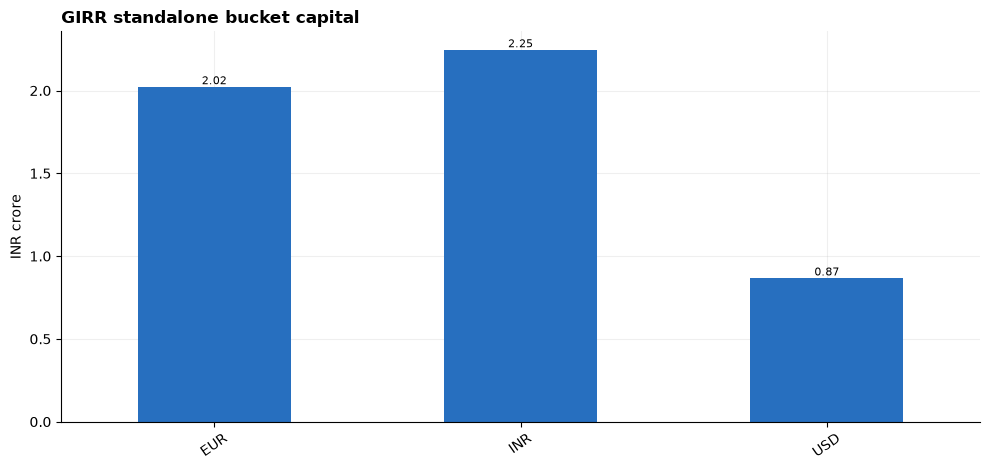

In [4]:
bar_crore(sample.set_index('bucket')['k_bucket'],'GIRR standalone bucket capital')

This produces one result for every scenario, risk class and sensitivity measure.